<a href="https://colab.research.google.com/github/epmbanten/Tugas-AI-602225073-Dody-Suhendra/blob/main/AHS_Classification_Inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step
Hasil Prediksi: Happy


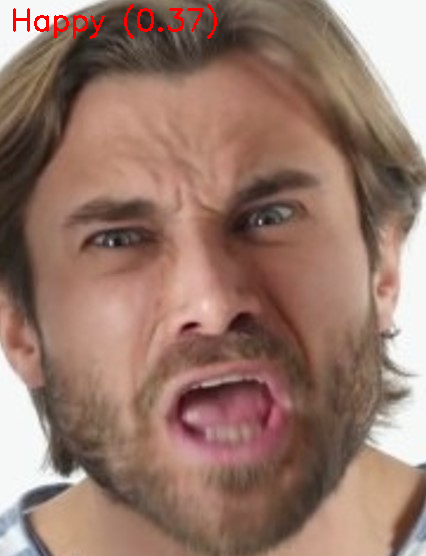

In [2]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from google.colab.patches import cv2_imshow # Ini adalah fungsi khusus pengganti cv2.imshow di Colab

def load_class_names(file_path):
    with open(file_path, 'r') as f:
        class_names = f.read().splitlines()
    return class_names

def preprocess_image(image, target_size):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, target_size)
    image = np.expand_dims(image, axis=0)
    return image

def main(source_path, model_path='AHSModel_TF2.17.0.keras', class_file='Class_Names.txt'):
    # Muat model dan nama kelas
    model = load_model(model_path)
    class_names = load_class_names(class_file)
    input_shape = (model.input_shape[2], model.input_shape[1])

    # Baca gambar
    frame = cv2.imread(source_path)

    if frame is None:
        print(f"Gambar {source_path} tidak ditemukan! Pastikan sudah diunggah ke Colab.")
        return

    # Proses prediksi
    image = preprocess_image(frame, input_shape)
    predictions = model.predict(image)
    class_id = np.argmax(predictions)
    class_name = class_names[class_id]
    probability = predictions[0][class_id]

    # Tampilkan hasil teks di atas gambar
    text = f"{class_name} ({probability:.2f})"
    cv2.putText(frame, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

    # Tampilkan gambar di output sel Colab
    print(f"Hasil Prediksi: {class_name}")
    cv2_imshow(frame)

# Cara menjalankannya:
# Pastikan nama file gambar sesuai dengan yang Anda unggah
main(source_path='Angry.jpg')